In [1]:
# Wolfram Language Imports
from wolframclient.evaluation import WolframLanguageSession
from wolframclient.language import wl, wlexpr
ws = WolframLanguageSession()

In [2]:
# Display Latex
from IPython.display import display, Math

# Display Plots
%matplotlib notebook
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [3]:
def print_tex(expr):
    """Prints an expression in latex"""
    display(Math(expr))

def print_wlresult(expr):
    """Prints a wolfram language result in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(expr)))
    display(Math(tex_expr))

def print_wlexpr(expr):
    """Prints a wolfram language expression in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(ws.evaluate(expr))))
    display(Math(tex_expr))
    
def wc(expr):
    """Evaluates an expression, stores, and prints the result"""
    result = ws.evaluate(expr)
    save_expr_str = 'rrr = {}'.format(expr)
    ws.evaluate(save_expr_str)
    print_wlresult(ws.evaluate('rrr'))
    return result

def wplot(filename, command):
    export_expr = 'Export["{}", {}]'.format(filename, command)
    wc(export_expr)
    fig, ax = plt.subplots(figsize=(7, 5))
    img = mpimg.imread(filename)
    ax.imshow(img)
    ax.axis('off')
    

print('\nPrinting latex:')
print_tex('\sum_{i=1}^{10} x_i')

print('\nPrinting the result of an evaluated expression:')
print_wlresult(ws.evaluate('x+2+y+3'))

print('\nEvaluating and printing an expression directly:')
print_wlexpr('Sum[x^k, {k, 0, 5}]')

print('\nEvaluating, storing, and printing reults:')
wc('Sum[x^k, {k, 0, 5}]')

print('\nAccessing those results in the variable "rrr":')
wc('rrr*10 + y')


Printing latex:


<IPython.core.display.Math object>


Printing the result of an evaluated expression:


<IPython.core.display.Math object>


Evaluating and printing an expression directly:


...


Evaluating, storing, and printing reults:


<IPython.core.display.Math object>


Accessing those results in the variable "rrr":


<IPython.core.display.Math object>

Plus[Times[10, Plus[1, Global`x, << 2 >>, Power[Global`x, 4], Power[Global`x, 5]]], Global`y]

In [45]:
wc('''
BigM = 5;
S = (Factorial[2M + 2])^(1/(2M+2));
''')

wc('''
Ti[_s, _z] := (1/2*I)*(PolyLog[s, I*z] - PolyLog[s, -I*z])
''')

wc('''
BigSCoef[M_, S_, j_] := EulerE[2*m]/(2*m)! \
+ (-1)^(M+1)*4/Pi * Sum[2^k * S^(j-k) * (1/2*I) * (PolyLog[k+1, I*Exp[-Pi/2*S]] - PolyLog[k+1, -I*Exp[-Pi/2*S]])  / (Pi^k * (j - k)!), {k, 0, j}]
'''
)

wc('''
SechApprox[_v] := Sum[BigSCoef[BigM, S, 2*m]*v^(2*m), {m, 0, M}]
''')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Javascript object>


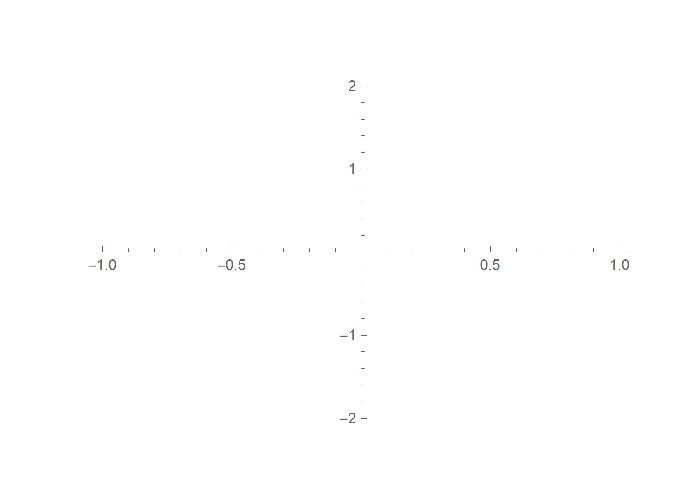

In [46]:
wplot("expansion.jpg", '''
Plot[
{SechApprox[v]}
, {v, -1, 1}, PlotRange -> {-2,2}]
''')

In [47]:
wc('''
Sum[BigSCoef[BigM, S, 2*m]*v^(2*m), {m, 0, M}]
''')

KeyboardInterrupt: 

In [48]:
ws.stop()